# Trade Reconciliation Automation with Python

**Objective:**  
Automate a basic trade reconciliation workflow comparing **internal trading records** with **external counterparty data**.  

**Key Features:**  
- Detects matches, mismatches, and missing trades  
- Generates a summary report  
- Visualizes reconciliation results  
- Exports results to Excel/CSV  

**Tech Used:** Python, pandas, matplotlib, Jupyter Notebook  

> This notebook simulates real finance operations and demonstrates both Python and finance process skills.

In [27]:
# ===============================
# Step 1: Import Libraries
# ===============================
import pandas as pd          # For data manipulation
import matplotlib.pyplot as plt  # For charts/visualizations

## Step 2: Create Internal & External Datasets

We simulate internal and external trading data with the following columns:
- `Trade_ID` → Unique identifier of the trade
- `Amount` → Trade value
- `Currency` → Currency of the trade

> In a real project, datasets would come from CSV, Excel, or internal systems.

In [28]:
# Internal trade data
internal_data = pd.DataFrame({
    'Trade_ID': [1, 2, 3, 4, 5],
    'Amount': [100000, 250000, 175000, 300000, 225000],
    'Currency': ['USD', 'EUR', 'GBP', 'USD', 'EUR']
})

# External trade data
external_data = pd.DataFrame({
    'Trade_ID': [1, 2, 3, 4, 6],
    'Amount': [100000, 250000, 180000, 300000, 50000],
    'Currency': ['USD', 'EUR', 'GBP', 'USD', 'EUR']
})

# Preview the datasets
print("Internal Data:")
print(internal_data)
print("\nExternal Data:")
print(external_data)

Internal Data:
   Trade_ID  Amount Currency
0         1  100000      USD
1         2  250000      EUR
2         3  175000      GBP
3         4  300000      USD
4         5  225000      EUR

External Data:
   Trade_ID  Amount Currency
0         1  100000      USD
1         2  250000      EUR
2         3  180000      GBP
3         4  300000      USD
4         6   50000      EUR


## Step 3: Merge Datasets

We merge internal and external datasets using `Trade_ID` as the key with an **outer join**.

- Ensures **all trades** are included, even if missing on one side
- `suffixes=('_internal', '_external')` → differentiates columns

In [29]:
merged_data = pd.merge(
    internal_data,
    external_data,
    on='Trade_ID',
    how='outer',
    suffixes=('_internal', '_external')
)

# Preview merged dataset
print(merged_data)

   Trade_ID  Amount_internal Currency_internal  Amount_external  \
0         1         100000.0               USD         100000.0   
1         2         250000.0               EUR         250000.0   
2         3         175000.0               GBP         180000.0   
3         4         300000.0               USD         300000.0   
4         5         225000.0               EUR              NaN   
5         6              NaN               NaN          50000.0   

  Currency_external  
0               USD  
1               EUR  
2               GBP  
3               USD  
4               NaN  
5               EUR  


## Step 4: Define Reconciliation Logic

Each trade is checked for:
1. Missing internal data → "Missing Internal"
2. Missing external data → "Missing External"
3. Amount or currency mismatch → "Mismatch"
4. Exact match → "Match"

In [30]:
def reconcile(row):
    # Check for missing internal data
    if pd.isna(row['Amount_internal']) or pd.isna(row['Currency_internal']):
        return 'Missing Internal'
    
    # Check for missing external data
    elif pd.isna(row['Amount_external']) or pd.isna(row['Currency_external']):
        return 'Missing External'
    
    # Check for mismatch in Amount or Currency
    elif (row['Amount_internal'] != row['Amount_external']) or (row['Currency_internal'] != row['Currency_external']):
        return 'Mismatch'
    
    # If everything matches
    else:
        return 'Match'

## Step 5: Apply Reconciliation

- Apply the `reconcile` function to each row of the merged dataset
- Creates a new column `Status` to indicate the reconciliation result

In [31]:
merged_data['Status'] = merged_data.apply(reconcile, axis=1)

# Preview dataset with Status
print(merged_data)

   Trade_ID  Amount_internal Currency_internal  Amount_external  \
0         1         100000.0               USD         100000.0   
1         2         250000.0               EUR         250000.0   
2         3         175000.0               GBP         180000.0   
3         4         300000.0               USD         300000.0   
4         5         225000.0               EUR              NaN   
5         6              NaN               NaN          50000.0   

  Currency_external            Status  
0               USD             Match  
1               EUR             Match  
2               GBP          Mismatch  
3               USD             Match  
4               NaN  Missing External  
5               EUR  Missing Internal  


## Step 6: Summary Report

- Count the number of trades in each reconciliation category:
  - Match
  - Mismatch
  - Missing Internal
  - Missing External
- Provides a quick overview for stakeholders

In [32]:
summary = merged_data['Status'].value_counts()

print("===== Summary Report =====")
print(summary)

===== Summary Report =====
Status
Match               3
Mismatch            1
Missing External    1
Missing Internal    1
Name: count, dtype: int64


## Step 7: Visualization

- Bar chart to show reconciliation results
- Colors indicate status (green = match, red = mismatch, orange = missing)

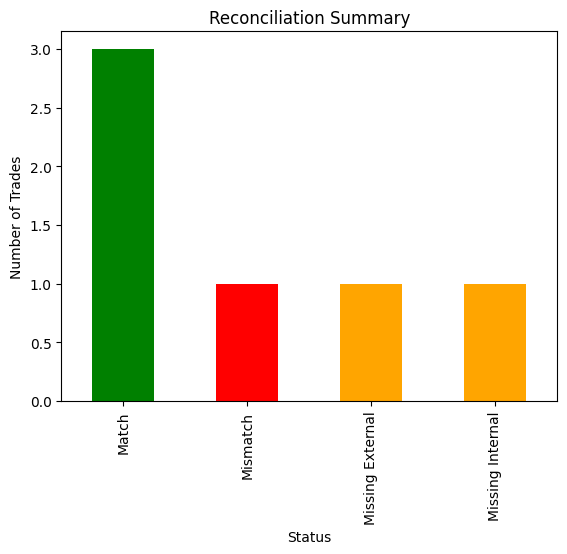

In [33]:
summary.plot(kind='bar', color=['green','red','orange','orange'])
plt.title('Reconciliation Summary')
plt.xlabel('Status')
plt.ylabel('Number of Trades')
plt.show()

## Step 8: Export Results

- Export full reconciliation dataset and summary to Excel and CSV
- Requires `openpyxl` library to write Excel files

In [34]:
# Export to Excel
merged_data.to_excel('reconciliation_results.xlsx', index=False)
summary.to_excel('reconciliation_summary.xlsx')

# Optional: export to CSV
merged_data.to_csv('reconciliation_results.csv', index=False)
summary.to_csv('reconciliation_summary.csv')

# Conclusion

This notebook demonstrates:
- Data handling with **pandas**
- Reconciliation logic for finance operations
- Summary reporting and visualization
- Exporting results to Excel/CSV

**Next Steps:**
- Replace simulated datasets with **real trade data**
- Automate reading data from CSV or database
- Extend to handle **multi-currency or multi-asset reconciliation**

In [35]:
%pip freeze > requirements.txt

14279.24s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.
